# Аналитика: Анализ данных CRM

Ноутбук содержит аналитический разбор по очищенным данным.

**Бизнес-контекст:**
- Конверсия = `is_buyer` (первый платёж получен + месяцы обучения > 0)
- Выручка = `initial_amount_paid` (фактически полученные деньги)

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import json
import folium
from geopy.distance import geodesic

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

CLEANED_DIR = os.path.join('..', 'data', 'cleaned')

In [24]:
contacts      = pd.read_pickle(os.path.join(CLEANED_DIR, 'contacts_clean.pkl'))
deals         = pd.read_pickle(os.path.join(CLEANED_DIR, 'deals_clean.pkl'))
calls         = pd.read_pickle(os.path.join(CLEANED_DIR, 'calls_clean.pkl'))
spend         = pd.read_pickle(os.path.join(CLEANED_DIR, 'spend_clean.pkl'))
# campaign_romi — агрегат из 05_data_merging.ipynb (единственный источник правды для ROMI)
campaign_romi = pd.read_pickle(os.path.join(CLEANED_DIR, 'campaign_romi.pkl'))

print(f'Contacts:      {contacts.shape}')
print(f'Deals:         {deals.shape}')
print(f'Calls:         {calls.shape}')
print(f'Spend:         {spend.shape}')
print(f'Campaign ROMI: {campaign_romi.shape}')

Contacts:      (18510, 7)
Deals:         (19815, 28)
Calls:         (92599, 9)
Spend:         (19862, 8)
Campaign ROMI: (366, 12)


## Описательная статистика

Базовые показатели по всем датасетам: числовые поля (mean, median, mode, range) и
распределение категориальных переменных (quality, stage_group, source, product,
payment_type, level_of_deutsch).


In [25]:

# Числовая статистика: mean / median / mode / range 

def num_stats(df, cols, label):
    """Сводная таблица mean/median/mode/range для числовых колонок датасета."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        mode_val = s.mode()
        rows.append({
            'Поле':   col,
            'Count':  len(s),
            'Mean':   round(s.mean(), 2),
            'Median': round(s.median(), 2),
            'Mode':   round(mode_val.iloc[0], 2) if len(mode_val) else None,
            'Std':    round(s.std(), 2),
            'Min':    round(s.min(), 2),
            'Max':    round(s.max(), 2),
            'Range':  round(s.max() - s.min(), 2),
        })
    return pd.DataFrame(rows)

fmt = {
    'Count':  '{:,.0f}',
    'Mean':   '{:,.2f}',
    'Median': '{:,.2f}',
    'Mode':   '{:,.2f}',
    'Std':    '{:,.2f}',
    'Min':    '{:,.2f}',
    'Max':    '{:,.2f}',
    'Range':  '{:,.2f}',
}

buyers = deals[deals['is_buyer'] == 1]

# ── 1. Сделки (только клиенты) ──────────────────────────────────────────────
buyer_cols = [
    'initial_amount_paid',
    'offer_total_amount',
    'course_duration',
    'months_of_study',
    'deal_duration_days',
    'sla_filled',
]
stats_buyers = num_stats(buyers, buyer_cols, 'Deals (клиенты)')

print('═' * 70)
print(f'  СДЕЛКИ — клиенты (n={len(buyers):,},  CR = {len(buyers)/len(deals)*100:.1f}%)')
print('═' * 70)
display(
    stats_buyers.set_index('Поле')
    .style.format(fmt)
    .set_caption(f'Финансовые и операционные метрики — только подтверждённые покупатели (is_buyer=True)')
)

# ── 2. Сделки (все) ──────────────────────────────────────────────────────────
all_cols = [
    'initial_amount_paid',
    'offer_total_amount',
    'course_duration',
    'months_of_study',
    'deal_duration_days',
    'sla_filled',
]
stats_all = num_stats(deals, all_cols, 'Deals (все)')

print()
print('═' * 70)
print(f'  СДЕЛКИ — все лиды (n={len(deals):,})')
print('═' * 70)
display(
    stats_all.set_index('Поле')
    .style.format(fmt)
    .set_caption('Те же поля по всему датасету (включая лидов без оплаты) — для сравнения распределений')
)

# ── 3. Звонки ────────────────────────────────────────────────────────────────
calls_ok = calls[calls['is_successful'] == True]
n_failed  = len(calls) - len(calls_ok)
stats_calls = num_stats(calls_ok, ['call_duration_in_seconds'], 'Calls')

print()
print('═' * 70)
print(f'  ЗВОНКИ — успешные: {len(calls_ok):,}  |  неуспешные: {n_failed:,}  |  всего: {len(calls):,}')
print('═' * 70)
display(
    stats_calls.set_index('Поле')
    .style.format(fmt)
    .set_caption('Длительность звонков — только успешные (is_successful=True)')
)


══════════════════════════════════════════════════════════════════════
  СДЕЛКИ — клиенты (n=826,  CR = 4.2%)
══════════════════════════════════════════════════════════════════════


,Count,Mean,Median,Mode,Std,Min,Max,Range
Поле,,,,,,,,
initial_amount_paid,826,"1,140.25","1,000.00","1,000.00","1,471.31",100.00,"11,500.00","11,400.00"
offer_total_amount,826,"7,673.00","11,000.00","11,000.00","3,718.90","1,200.00","11,500.00","10,300.00"
course_duration,826,10.17,11.00,11.00,1.86,6.00,11.00,5.00
months_of_study,826,5.45,5.00,6.00,2.92,1.00,11.00,10.00
deal_duration_days,505,32.66,16.00,0.00,42.89,0.00,304.00,304.00
sla_filled,826,368.74,221.00,221.00,375.81,1.00,"1,419.00","1,418.00"



══════════════════════════════════════════════════════════════════════
  СДЕЛКИ — все лиды (n=19,815)
══════════════════════════════════════════════════════════════════════


,Count,Mean,Median,Mode,Std,Min,Max,Range
Поле,,,,,,,,
initial_amount_paid,"19,815",193.30,0.00,0.00,742.34,0.00,"11,500.00","11,500.00"
offer_total_amount,"19,815","1,621.84",0.00,0.00,"3,727.94",0.00,"11,500.00","11,500.00"
course_duration,"19,815",1.82,0.00,0.00,3.98,0.00,11.00,11.00
months_of_study,"19,815",0.23,0.00,0.00,1.25,0.00,11.00,11.00
deal_duration_days,"13,135",15.26,3.00,0.00,32.25,0.00,334.00,334.00
sla_filled,"19,815",362.78,236.00,189.00,348.49,0.00,"1,438.00","1,438.00"



══════════════════════════════════════════════════════════════════════
  ЗВОНКИ — успешные: 72,590  |  неуспешные: 20,009  |  всего: 92,599
══════════════════════════════════════════════════════════════════════


,Count,Mean,Median,Mode,Std,Min,Max,Range
Поле,,,,,,,,
call_duration_in_seconds,"72,590",217.10,22.00,5.00,448.20,1.00,"7,625.00","7,624.00"


══════════════════════════════════════════════════════════════════════
  КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ — распределение значений
══════════════════════════════════════════════════════════════════════



Deals — Качество лида (quality)
          quality  Count     %
E - Non Qualified   6143 31.00
   D - Non Target   6078 30.70
          C - Low   3403 17.20
          Unknown   2230 11.30
       B - Medium   1543  7.80
         A - High    418  2.10

Deals — Стадия воронки (stage_group)
   stage_group  Count     %
          Lost  13996 70.60
  Active Sales   2808 14.20
Marketing/Lead   2155 10.90
      Won/Paid    856  4.30

Deals — Источник трафика (source)
        source  Count     %
  Facebook Ads   4726 23.90
    Google Ads   4113 20.80
    Tiktok Ads   2003 10.10
           SMM   1667  8.40
   Youtube Ads   1618  8.20
       Organic   1469  7.40
           CRM   1454  7.40
      Bloggers   1073  5.40
Telegram posts    993  5.00
       Webinar    305  1.50
   Partnership    189  1.00
          Test    156  0.80

Deals — Продукт (product)
            product  Count     %
            Unknown  16278 82.10
  Digital Marketing   1953  9.90
       UX/UI Design   1013  5.10
      Web Deve

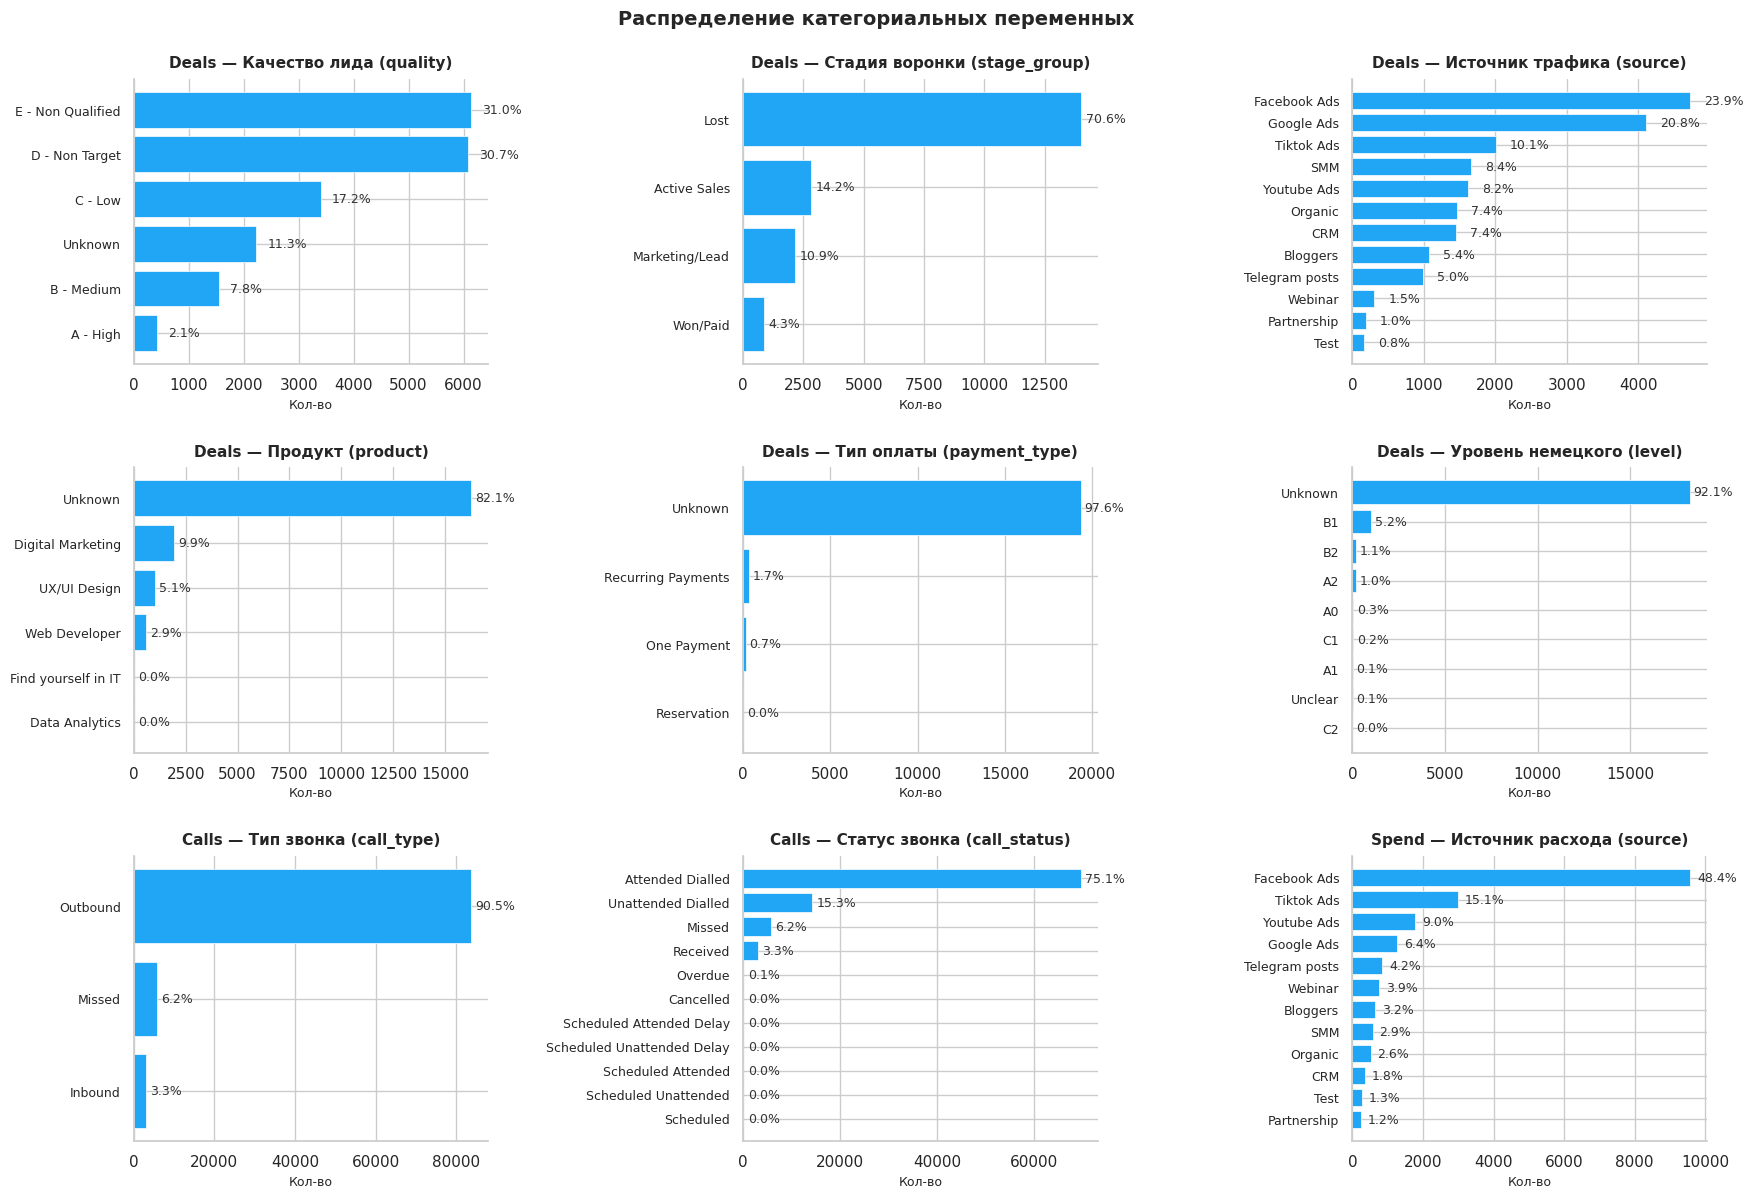

In [26]:

# Категориальные переменные

cat_fields = {
    'Deals — Качество лида (quality)':        ('deals',    'quality'),
    'Deals — Стадия воронки (stage_group)':   ('deals',    'stage_group'),
    'Deals — Источник трафика (source)':      ('deals',    'source'),
    'Deals — Продукт (product)':              ('deals',    'product'),
    'Deals — Тип оплаты (payment_type)':      ('deals',    'payment_type'),
    'Deals — Уровень немецкого (level)':      ('deals',    'level_of_deutsch'),
    'Calls — Тип звонка (call_type)':         ('calls',    'call_type'),
    'Calls — Статус звонка (call_status)':    ('calls',    'call_status'),
    'Spend — Источник расхода (source)':      ('spend',    'source'),
}

data_map = {'deals': deals, 'calls': calls, 'spend': spend}

print('═' * 70)
print('  КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ — распределение значений')
print('═' * 70)

n_plots = len(cat_fields)
cols_per_row = 3
rows_count   = (n_plots + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows_count, cols_per_row,
                         figsize=(18, rows_count * 4))
axes = axes.flatten()

for ax_idx, (title, (ds_key, col)) in enumerate(cat_fields.items()):
    df_src = data_map[ds_key]
    if col not in df_src.columns:
        axes[ax_idx].set_visible(False)
        continue

    vc = df_src[col].value_counts().head(12)
    total = vc.sum()

    bars = axes[ax_idx].barh(
        vc.index.astype(str)[::-1],
        vc.values[::-1],
        color='#21A6F5', edgecolor='white', linewidth=0.5
    )
    # Подписи %
    for bar, val in zip(bars, vc.values[::-1]):
        pct = val / total * 100
        axes[ax_idx].text(
            bar.get_width() + total * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center', fontsize=9, color='#333'
        )

    axes[ax_idx].set_title(title, fontsize=11, fontweight='bold', pad=8)
    axes[ax_idx].set_xlabel('Кол-во', fontsize=9)
    axes[ax_idx].tick_params(axis='y', labelsize=9)
    axes[ax_idx].spines[['top', 'right']].set_visible(False)

    # Текстовая таблица под графиком
    print(f'\n{title}')
    tbl = vc.reset_index()
    tbl.columns = [col, 'Count']
    tbl['%'] = (tbl['Count'] / total * 100).round(1)
    print(tbl.to_string(index=False))

# Скрываем лишние оси
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.tight_layout(pad=2.0)
plt.suptitle('Распределение категориальных переменных', fontsize=14,
             fontweight='bold', y=1.01)
plt.show()


## 1. Анализ временных рядов

### 1.1 Тренд создания сделок и звонков во времени

Сравниваем помесячную динамику создания сделок с активностью по звонкам. Визуализация и помесячные результаты выводятся как дашборд с помощью библиотеки Dash

In [27]:
# Подготовка данных

# Анализ менеджеров (Проблемы закрытия сделок)
has_duration = 'duration_raw' in deals.columns and 'deal_duration_days' in deals.columns

mgr_agg_spec = {
    'total_deals': ('id', 'count'),
    'won_deals':   ('is_buyer', 'sum'),
}
if has_duration:
    mgr_agg_spec['neg_duration_count'] = ('duration_raw', lambda x: (x < 0).sum())
    mgr_agg_spec['avg_duration']       = ('deal_duration_days', 'mean')

mgr_anomalies = deals.groupby('deal_owner_name', observed=True).agg(**mgr_agg_spec).reset_index()

# zero_payment_won считаем отдельно
zero_mask = (deals['stage_group'] == 'Won/Paid') & (deals['initial_amount_paid'] == 0)
mgr_anomalies['zero_payment_won'] = (
    deals[zero_mask].groupby('deal_owner_name', observed=True)['id'].count()
    .reindex(mgr_anomalies['deal_owner_name']).fillna(0).values
)

if not has_duration:
    mgr_anomalies['neg_duration_count'] = 0
    mgr_anomalies['avg_duration'] = 0

mgr_anomalies['anomaly_rate']    = (mgr_anomalies['neg_duration_count'] / mgr_anomalies['total_deals'] * 100).round(1)
mgr_anomalies['conversion_rate'] = (mgr_anomalies['won_deals'] / mgr_anomalies['total_deals'] * 100).round(1)
mgr_anomalies = mgr_anomalies[mgr_anomalies['total_deals'] > 5].sort_values('neg_duration_count', ascending=False)

# Агрегация сделок по месяцам для основного дашборда
deals['month'] = deals['created_time'].dt.to_period('M')
deals_monthly = deals.groupby('month').agg(
    total_deals=('id', 'count'),
    won_deals=('is_buyer', 'sum'),
    revenue=('initial_amount_paid', 'sum')
).reset_index()
deals_monthly['month_dt'] = deals_monthly['month'].dt.to_timestamp()
deals_monthly['conversion_rate'] = (deals_monthly['won_deals'] / deals_monthly['total_deals'] * 100).round(1)

# Агрегация звонков
date_col = calls.select_dtypes('datetime').columns[0]
calls['month'] = calls[date_col].dt.to_period('M')
calls_monthly = calls.groupby('month').size().reset_index(name='total_calls')
calls_monthly['month_dt'] = calls_monthly['month'].dt.to_timestamp()

# Агрегация расходов
spend['month'] = spend['date'].dt.to_period('M')
spend_monthly = spend.groupby('month').agg(
    total_spend=('spend', 'sum'),
    total_clicks=('clicks', 'sum')
).reset_index()
spend_monthly['month_dt'] = spend_monthly['month'].dt.to_timestamp()

# Смерджим всё в одну таблицу для дашборда
merged = (
    deals_monthly
    .merge(calls_monthly[['month_dt', 'total_calls']], on='month_dt', how='left')
    .merge(spend_monthly[['month_dt', 'total_spend', 'total_clicks']], on='month_dt', how='left')
).fillna(0)

merged['cac']  = (merged['total_spend'] / merged['won_deals']).replace([np.inf, -np.inf, np.nan], 0)
merged['romi'] = ((merged['revenue'] - merged['total_spend']) / merged['total_spend'] * 100).replace([np.inf, -np.inf, np.nan], 0)

# ROMI по источникам трафика
# Берём уже рассчитанный агрегат из 05_data_merging.ipynb (campaign_romi.pkl)
# Группируем по source — так получаем срез уровня канала
source_romi = (
    campaign_romi.groupby('source', observed=True)
    .agg(deals_count=('deals_count', 'sum'), buyers_count=('buyers_count', 'sum'),
         revenue=('revenue', 'sum'), total_spend=('total_spend', 'sum'))
    .reset_index()
)
source_romi['conversion_rate'] = (source_romi['buyers_count'] / source_romi['deals_count'].replace(0, np.nan) * 100).round(1).fillna(0)
source_romi['romi'] = ((source_romi['revenue'] - source_romi['total_spend']) / source_romi['total_spend'].replace(0, np.nan) * 100).round(1).fillna(0)
source_romi['cac']  = (source_romi['total_spend'] / source_romi['buyers_count'].replace(0, np.nan)).round(0).fillna(0)
source_romi = source_romi.sort_values('revenue', ascending=False)

# Список доступных месяцев для фильтра
available_months = sorted(merged['month'].astype(str).unique(), reverse=True)

# Функция для бизнес-выводов ---
def get_insights_html(selected_month_str):
    df_filtered = merged[merged['month'].astype(str) == selected_month_str]
    if df_filtered.empty:
        return html.Div("Нет данных за выбранный период")
    
    row = df_filtered.iloc[0]
    all_months = sorted(merged['month'].unique())
    curr_idx = all_months.index(pd.Period(selected_month_str, freq='M'))
    
    growth_text = ""
    if curr_idx > 0:
        prev_month_data = merged[merged['month'] == all_months[curr_idx-1]]
        if not prev_month_data.empty:
            prev_rev = prev_month_data.iloc[0]['revenue']
            if prev_rev > 0:
                growth = ((row['revenue'] - prev_rev) / prev_rev * 100)
                growth_text = f" (изменение к прошлому месяцу: {growth:+.1f}%)"

    romi_status = "положительный" if row['romi'] > 0 else "отрицательный"

    return html.Div([
        html.H4(f"Бизнес-инсайт за {selected_month_str}:", style={'color': '#2c3e50'}),
        html.Ul([
            html.Li(f"Выручка составила {row['revenue']:,.0f} €{growth_text}"),
            html.Li(f"ROMI {romi_status}: {row['romi']:.1f}%"),
            html.Li(f"Средняя стоимость привлечения (CAC): {row['cac']:,.0f} €"),
            html.Li(f"Конверсия в покупку: {row['conversion_rate']:.1f}%")
        ])
    ], style={'backgroundColor': '#ecf0f1', 'padding': '15px', 'borderLeft': '5px solid #3498db', 'marginBottom': '20px'})

# Dash App
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Интерактивный дашборд аналитики", style={'textAlign': 'center', 'color': '#2c3e50', 'marginBottom': '30px'}),
    
    html.Div([
        html.Label("Выберите месяц для анализа:", style={'fontWeight': 'bold'}),
        dcc.Dropdown(
            id='month-selector',
            options=[{'label': m, 'value': m} for m in available_months],
            value=available_months[0],
            clearable=False
        )
    ], style={'marginBottom': '20px', 'width': '300px'}),

    html.Div(id='business-insights-container'),
    
    html.Div([
        html.Div([
            html.Label("Визуализация:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='view-selector',
                options=[
                    {'label': 'Сделки и Конверсия',          'value': 'deals'},
                    {'label': 'Активность (Звонки)',          'value': 'calls'},
                    {'label': 'Экономика (Выручка vs Расходы)', 'value': 'finance'},
                    {'label': 'Эффективность (ROMI)',         'value': 'romi'},
                    {'label': 'ROMI по источникам',           'value': 'source_romi'},
                    {'label': 'Анализ менеджеров (Аномалии)', 'value': 'managers'}
                ],
                value='finance',
                clearable=False
            )
        ], style={'width': '48%', 'display': 'inline-block'}),
        
        html.Div([
            html.Label("Отображение таблицы:", style={'fontWeight': 'bold'}),
            dcc.RadioItems(
                id='table-toggle',
                options=[{'label': 'Показать', 'value': 'on'}, {'label': 'Скрыть', 'value': 'off'}],
                value='on',
                inline=True,
                style={'padding': '5px'}
            )
        ], style={'width': '48%', 'display': 'inline-block', 'float': 'right'})
    ], style={'marginBottom': '20px'}),
    
    dcc.Graph(id='main-graph'),
    
    html.Div(id='table-wrapper', children=[
        html.H3("Детальные данные", style={'color': '#2c3e50'}),
        html.Div(id='table-container')
    ], style={'marginTop': '30px'})
], style={'padding': '30px', 'fontFamily': 'Segoe UI, Arial, sans-serif', 'backgroundColor': '#fcfcfc'})

@app.callback(
    [Output('main-graph', 'figure'),
     Output('table-container', 'children'),
     Output('table-wrapper', 'style'),
     Output('business-insights-container', 'children')],
    [Input('view-selector', 'value'),
     Input('table-toggle', 'value'),
     Input('month-selector', 'value')]
)
def update_dashboard(selected_view, table_status, selected_month):
    try:
        fig = make_subplots(rows=1, cols=1, specs=[[{"secondary_y": (selected_view in ['deals', 'managers', 'source_romi'])}]])
        
        if selected_view == 'deals':
            fig.add_trace(go.Bar(x=merged['month_dt'], y=merged['total_deals'], name="Все сделки", marker_color='steelblue'), row=1, col=1)
            fig.add_trace(go.Bar(x=merged['month_dt'], y=merged['won_deals'], name="Покупки", marker_color='#2ecc71'), row=1, col=1)
            fig.add_trace(go.Scatter(x=merged['month_dt'], y=merged['conversion_rate'], name="Конверсия %", line=dict(color='crimson')), row=1, col=1, secondary_y=True)
            fig.update_yaxes(title_text="Количество", secondary_y=False)
            fig.update_yaxes(title_text="%", secondary_y=True)

        elif selected_view == 'calls':
            fig.add_trace(go.Scatter(x=merged['month_dt'], y=merged['total_calls'], name="Звонки", line=dict(color='darkorange', width=3), mode='lines+markers'), row=1, col=1)
            fig.update_yaxes(title_text="Кол-во звонков")

        elif selected_view == 'finance':
            fig.add_trace(go.Scatter(x=merged['month_dt'], y=merged['revenue'], name="Выручка (€)", line=dict(color='#8b4513', width=3)), row=1, col=1)
            fig.add_trace(go.Scatter(x=merged['month_dt'], y=merged['total_spend'], name="Расходы (€)", line=dict(color='red', dash='dash', width=2)), row=1, col=1)
            fig.update_yaxes(title_text="Сумма (€)")

        elif selected_view == 'romi':
            colors = ['#27ae60' if x > 0 else '#e74c3c' for x in merged['romi']]
            fig.add_trace(go.Bar(x=merged['month_dt'], y=merged['romi'], name="ROMI %", marker_color=colors), row=1, col=1)
            fig.update_yaxes(title_text="ROMI %")

        elif selected_view == 'source_romi':
            sr = source_romi.copy()
            romi_colors = ['#27ae60' if x > 0 else '#e74c3c' for x in sr['romi']]
            fig.add_trace(go.Bar(x=sr['source'], y=sr['revenue'],     name="Выручка (€)", marker_color='#8b4513'), row=1, col=1)
            fig.add_trace(go.Bar(x=sr['source'], y=sr['total_spend'], name="Расходы (€)", marker_color='red'),     row=1, col=1)
            fig.add_trace(go.Scatter(x=sr['source'], y=sr['romi'], name="ROMI %",
                                     line=dict(color='navy', width=2), mode='lines+markers',
                                     marker=dict(color=romi_colors, size=10)),
                         row=1, col=1, secondary_y=True)
            fig.update_layout(barmode='group', title="ROMI по источникам трафика")
            fig.update_yaxes(title_text="Сумма (€)", secondary_y=False)
            fig.update_yaxes(title_text="ROMI %", secondary_y=True)

        elif selected_view == 'managers':
            m_top = mgr_anomalies.head(15)
            fig.add_trace(go.Bar(x=m_top['deal_owner_name'], y=m_top['neg_duration_count'], 
                               name="Отриц. длительность (шт)", marker_color='#e67e22'), row=1, col=1)
            fig.add_trace(go.Bar(x=m_top['deal_owner_name'], y=m_top['zero_payment_won'], 
                               name="Успех с 0 оплатой (шт)", marker_color='#c0392b'), row=1, col=1)
            fig.add_trace(go.Scatter(x=m_top['deal_owner_name'], y=m_top['anomaly_rate'], 
                                   name="% Аномалий", line=dict(color='#2c3e50', width=2), mode='lines+markers'), 
                        row=1, col=1, secondary_y=True)
            fig.update_layout(barmode='group', title="Топ-15 менеджеров по техническим ошибкам в сделках")
            fig.update_yaxes(title_text="Количество ошибок", secondary_y=False)
            fig.update_yaxes(title_text="% от всех сделок менеджера", secondary_y=True)

        fig.update_layout(height=500, margin=dict(l=20, r=20, t=60, b=20), hovermode='x unified', showlegend=True, 
                         plot_bgcolor='white', paper_bgcolor='white')
        fig.update_xaxes(showgrid=False)
        fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0')
        
        table_style = {'display': 'block'} if table_status == 'on' else {'display': 'none'}
        
        if selected_view == 'managers':
            df_show = mgr_anomalies.copy()
        elif selected_view == 'source_romi':
            df_show = source_romi.copy()
        else:
            df_show = merged.copy()
            df_show['month'] = df_show['month'].astype(str)
        
        table = html.Table([
            html.Thead(html.Tr([html.Th(c, style={'padding': '12px', 'borderBottom': '2px solid #3498db', 'backgroundColor': '#f8f9fa', 'color': '#2c3e50'}) for c in df_show.columns])),
            html.Tbody([
                html.Tr([
                    html.Td(f"{df_show.iloc[i][c]:,.0f}" if isinstance(df_show.iloc[i][c], (int, float)) else str(df_show.iloc[i][c]), 
                            style={'padding': '10px', 'borderBottom': '1px solid #eee', 'color': '#333'}) 
                    for c in df_show.columns
                ]) for i in range(len(df_show))
            ])
        ], style={'width': '100%', 'borderCollapse': 'collapse', 'textAlign': 'left', 'boxShadow': '0 2px 10px rgba(0,0,0,0.05)'})

        return fig, table, table_style, get_insights_html(selected_month)
        
    except Exception as e:
        import plotly.express as px
        return px.scatter(title=f"Error: {e}"), html.Div(f"Error: {e}"), {'display': 'block'}, html.Div()

if __name__ == '__main__':
    app.run(jupyter_mode='inline', height=1000, debug=True)

### Продолжительность сделок: от создания до закрытия

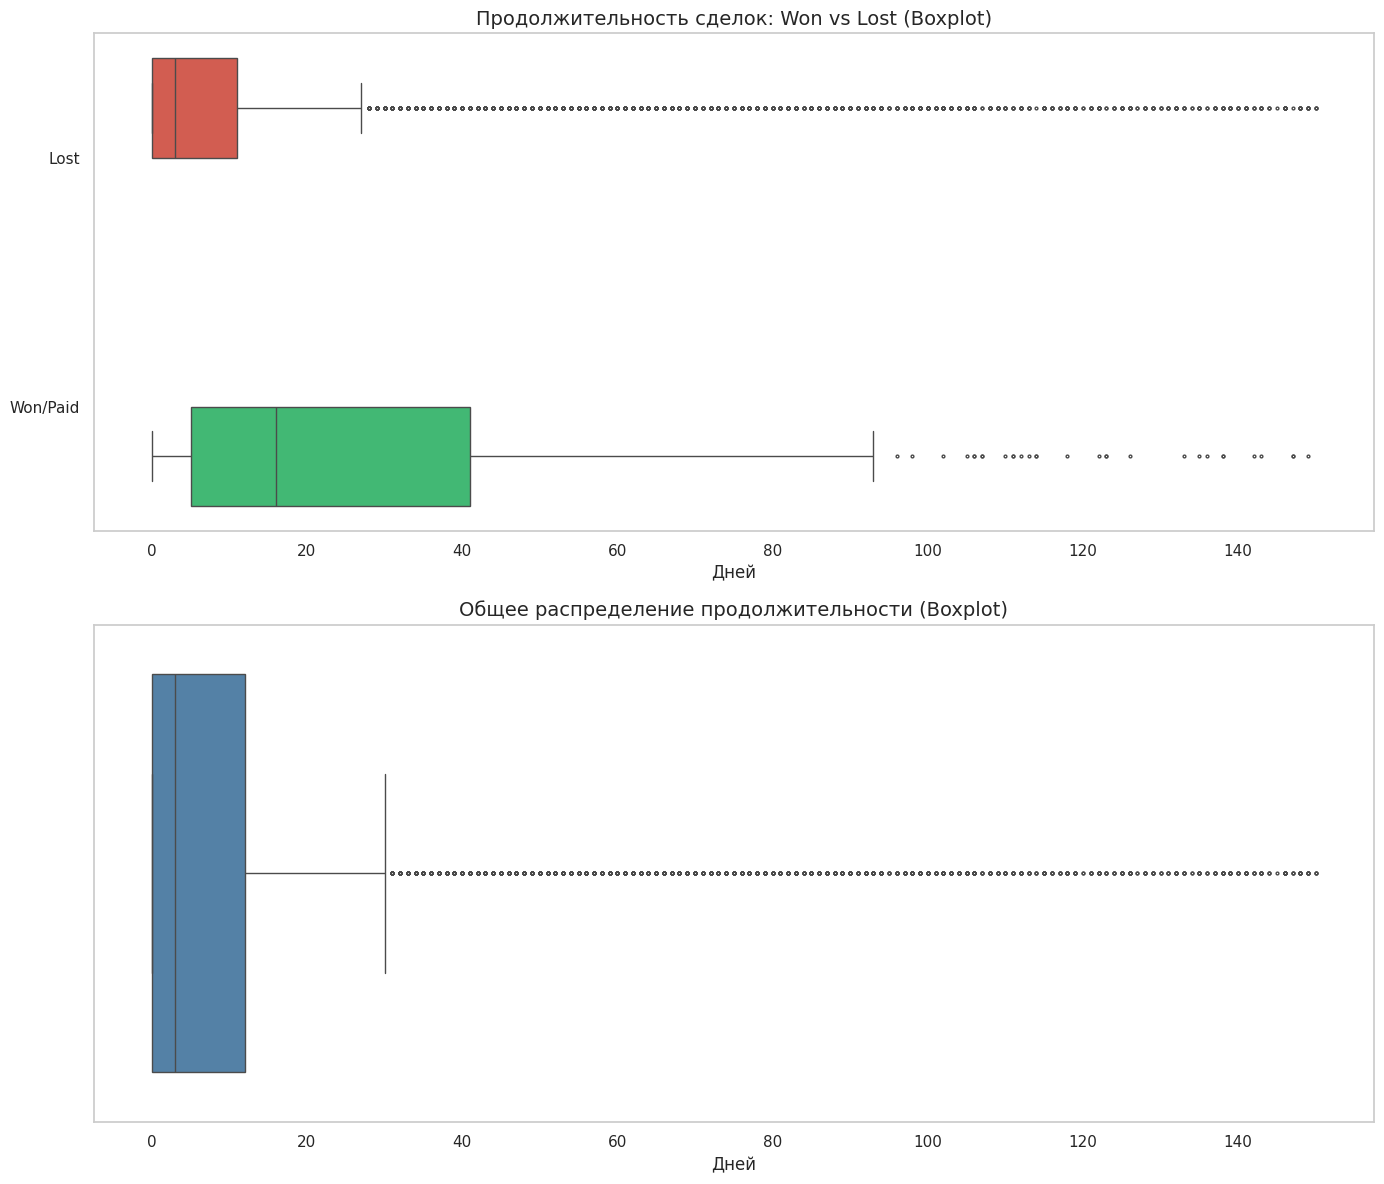

Статистика продолжительности (дни)


,count,mean,std,min,25%,50%,75%,90%,max
stage_group,,,,,,,,,
Lost,12209.00,12.20,24.10,0.00,0.00,3.00,11.00,38.00,150.00
Won/Paid,505.00,27.70,32.10,0.00,5.00,16.00,41.00,71.60,149.00


In [28]:
# Используем уже рассчитанную в 03_cleaning_deals.ipynb колонку deal_duration_days
# Фильтруем только закрытые сделки и убираем аномалии для наглядности
closed = deals[deals['closing_date'].notna()].copy()
closed = closed[(closed['deal_duration_days'] >= 0) & (closed['deal_duration_days'] <= 150)]

# Фильтруем данные и удаляем неиспользуемые категории для корректной работы
comparison_df = closed[closed['stage_group'].isin(['Won/Paid', 'Lost'])].copy()
if isinstance(comparison_df['stage_group'].dtype, pd.CategoricalDtype):
    comparison_df['stage_group'] = comparison_df['stage_group'].cat.remove_unused_categories()

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Сравнение Won vs Lost через боксплот
sns.boxplot(
    data=comparison_df,
    x='deal_duration_days', y='stage_group', 
    ax=axes[0], 
    hue='stage_group',
    palette={'Won/Paid': '#2ecc71', 'Lost': '#e74c3c'},
    fliersize=2,
    legend=False
)
axes[0].set_title('Продолжительность сделок: Won vs Lost (Boxplot)', fontsize=14)
axes[0].set_xlabel('Дней')
axes[0].set_ylabel('')
axes[0].grid(False)

# Общий боксплот по всей выборке
sns.boxplot(data=closed, x='deal_duration_days', ax=axes[1], color='steelblue', fliersize=2)
axes[1].set_title('Общее распределение продолжительности (Boxplot)', fontsize=14)
axes[1].set_xlabel('Дней')
axes[1].grid(False)

plt.tight_layout()
plt.show()

print('Статистика продолжительности (дни)')
display(
    comparison_df
    .groupby('stage_group', observed=True)['deal_duration_days']
    .describe(percentiles=[.25, .5, .75, .9])
    .round(1)
)

## Анализ эффективности кампаний

### Генерация лидов и конверсия по маркетинговым источникам (Source)

> **Вывод по источникам:**
> Основной кандидат на оптимизацию — **Google Ads**. Несмотря на то, что это крупнейший источник лидов, расходы по нему практически сравнимы с выручкой (самый низкий ROMI среди платных каналов). Необходимо детально проанализировать ключевые слова и таргетинг, чтобы снизить CAC.


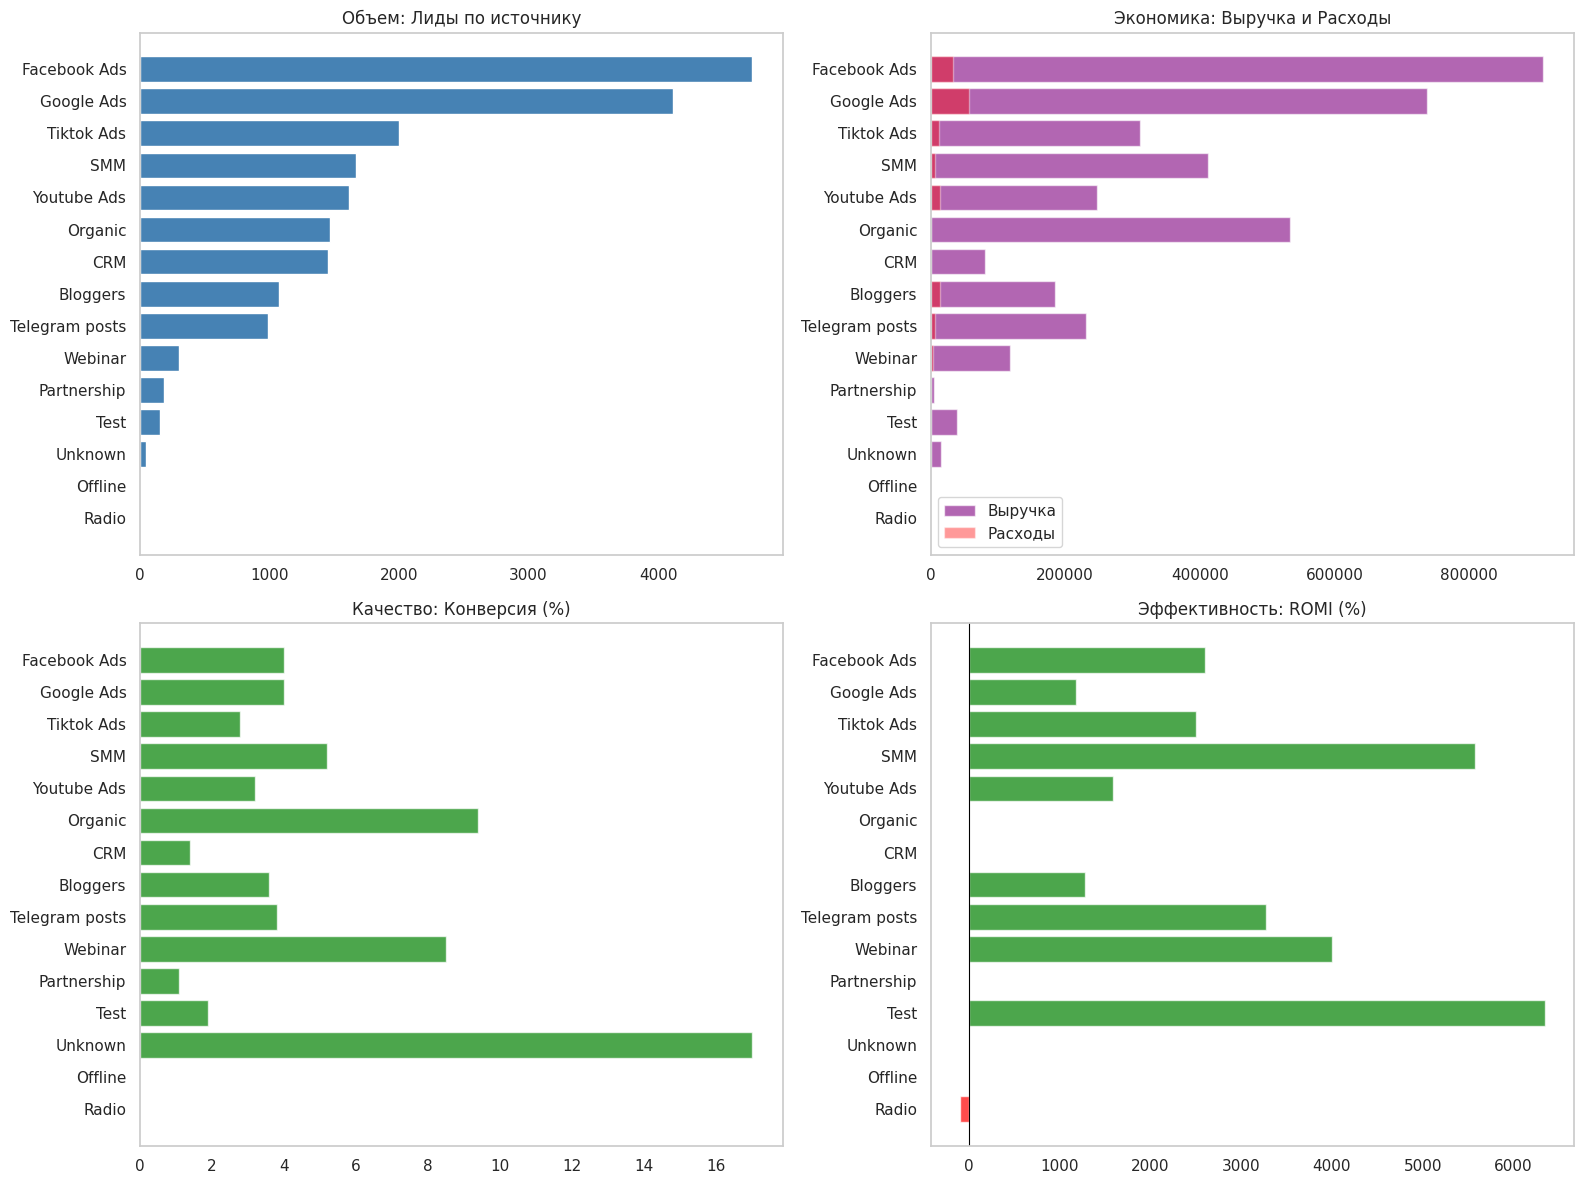

--- Эффективность маркетинговых источников (ROI/CAC) ---


,source,leads,buyers,revenue,avg_check,total_spend,cac,romi
2,Facebook Ads,4726,191.00,910500.00,4767.00,33754.72,177.00,2597.00
3,Google Ads,4113,166.00,738000.00,4446.00,57798.60,348.00,1177.00
11,Tiktok Ads,2003,56.00,311900.00,5570.00,11985.67,214.00,2502.00
8,SMM,1667,86.00,412650.00,4798.00,7269.52,85.00,5576.00
14,Youtube Ads,1618,52.00,246700.00,4744.00,14633.33,281.00,1586.00
5,Organic,1469,138.00,534310.00,3872.00,0.00,0.00,0.00
1,CRM,1454,21.00,81200.00,3867.00,0.00,0.00,0.00
0,Bloggers,1073,39.00,184800.00,4738.00,13439.00,345.00,1275.00
9,Telegram posts,993,38.00,231150.00,6083.00,6860.36,181.00,3269.00
13,Webinar,305,26.00,117850.00,4533.00,2874.04,111.00,4000.00


In [29]:
# Группируем campaign_romi
# Это единственный источник правды для метрик ROMI и CAC
source_stats = (
    campaign_romi.groupby('source', observed=True)
    .agg(
        leads=('deals_count', 'sum'),
        buyers=('buyers_count', 'sum'),       # T — транзакции покупателей
        revenue=('revenue', 'sum'),            # Rev — выручка
        total_spend=('total_spend', 'sum')
    )
    .reset_index()
    .assign(
        conversion_rate=lambda x: (x['buyers'] / x['leads'].replace(0, np.nan) * 100).fillna(0).round(1),
        avg_check=lambda x: (x['revenue'] / x['buyers'].replace(0, np.nan)).fillna(0).round(0),  # AOV = Rev / T
        cac=lambda x: (x['total_spend'] / x['buyers']).replace([np.inf, -np.inf], np.nan).fillna(0).round(0),
        romi=lambda x: ((x['revenue'] - x['total_spend']) / x['total_spend'].replace(0, np.nan) * 100).replace([np.inf, -np.inf], np.nan).fillna(0).round(0)
    )
    .sort_values('leads', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_sources = source_stats.sort_values('leads', ascending=True)
y_pos = range(len(top_sources))

axes[0, 0].barh(y_pos, top_sources['leads'], color='steelblue', label='Лиды')
axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels(top_sources['source'])
axes[0, 0].set_title('Объем: Лиды по источнику')
axes[0, 0].grid(False)

axes[0, 1].barh(y_pos, top_sources['revenue'], color='purple', alpha=0.6, label='Выручка')
axes[0, 1].barh(y_pos, top_sources['total_spend'], color='red', alpha=0.4, label='Расходы')
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels(top_sources['source'])
axes[0, 1].set_title('Экономика: Выручка и Расходы')
axes[0, 1].legend()
axes[0, 1].grid(False)

axes[1, 0].barh(y_pos, top_sources['conversion_rate'], color='green', alpha=0.7)
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(top_sources['source'])
axes[1, 0].set_title('Качество: Конверсия (%)')
axes[1, 0].grid(False)

colors = [('green' if x > 0 else 'red') for x in top_sources['romi']]
axes[1, 1].barh(y_pos, top_sources['romi'], color=colors, alpha=0.7)
axes[1, 1].axvline(0, color='black', linewidth=0.8)
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(top_sources['source'])
axes[1, 1].set_title('Эффективность: ROMI (%)')
axes[1, 1].grid(False)

plt.tight_layout()
plt.show()

print('--- Эффективность маркетинговых источников (ROI/CAC) ---')
display(source_stats[['source', 'leads', 'buyers', 'revenue', 'avg_check', 'total_spend', 'cac', 'romi']])


### Эффективность кампаний

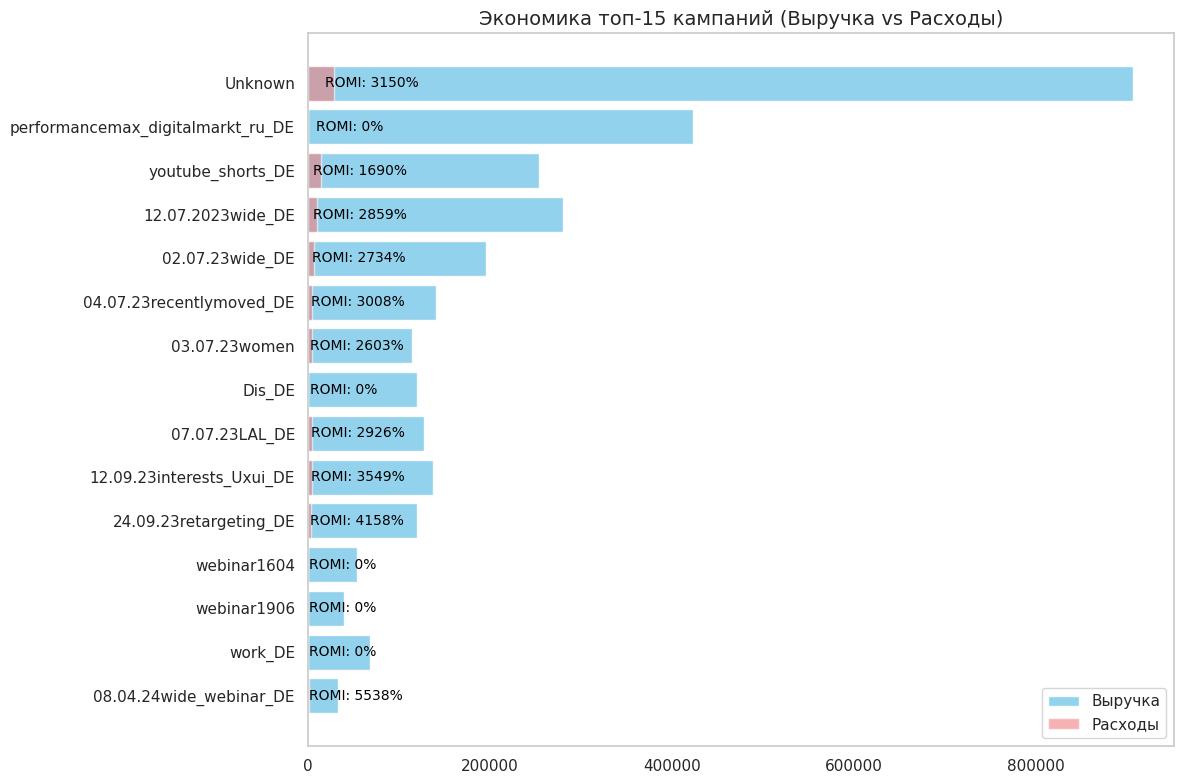

Детальная статистика по кампаниям (топ-20 по лидам)


,campaign,leads,buyers,revenue,avg_check,total_spend,romi,cac
77,Unknown,3424,226.00,906460.00,4011.00,27887.68,3150.00,123.00
123,performancemax_digitalmarkt_ru_DE,2682,108.00,422550.00,3912.00,0.00,0.00,0.00
156,youtube_shorts_DE,1662,52.00,253300.00,4871.00,14149.22,1690.00,272.00
20,12.07.2023wide_DE,1580,49.00,280300.00,5720.00,9471.52,2859.00,193.00
3,02.07.23wide_DE,990,51.00,195950.00,3842.00,6913.60,2734.00,136.00
6,04.07.23recentlymoved_DE,777,30.00,140600.00,4687.00,4523.31,3008.00,151.00
5,03.07.23women,623,28.00,114050.00,4073.00,4219.75,2603.00,151.00
66,Dis_DE,600,30.00,119250.00,3975.00,0.00,0.00,0.00
9,07.07.23LAL_DE,547,29.00,127100.00,4383.00,4200.37,2926.00,145.00
21,12.09.23interests_Uxui_DE,538,25.00,136950.00,5478.00,3753.06,3549.00,150.00


In [30]:
# Используем campaign_romi для анализа кампаний
campaign_stats = (
    campaign_romi.groupby('campaign', observed=True)
    .agg(
        leads=('deals_count', 'sum'),
        buyers=('buyers_count', 'sum'),       # T — транзакции покупателей
        revenue=('revenue', 'sum'),            # Rev — выручка
        total_spend=('total_spend', 'sum')
    )
    .reset_index()
    .assign(
        conversion_rate=lambda x: (x['buyers'] / x['leads'].replace(0, np.nan) * 100).fillna(0).round(1),
        avg_check=lambda x: (x['revenue'] / x['buyers'].replace(0, np.nan)).fillna(0).round(0),  # AOV = Rev / T
        cac=lambda x: (x['total_spend'] / x['buyers']).replace([np.inf, -np.inf], np.nan).fillna(0).round(0),
        romi=lambda x: ((x['revenue'] - x['total_spend']) / x['total_spend'].replace(0, np.nan) * 100).replace([np.inf, -np.inf], np.nan).fillna(0).round(0)
    )
    .sort_values('leads', ascending=False)
)

# Визуализация экономики топ-15 кампаний
top15_campaigns = campaign_stats.head(15).sort_values('leads', ascending=True)
y_pos = range(len(top15_campaigns))

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(y_pos, top15_campaigns['revenue'], color='skyblue', alpha=0.9, label='Выручка')
ax.barh(y_pos, top15_campaigns['total_spend'], color='lightcoral', alpha=0.6, label='Расходы')

for i, (romi, rev) in enumerate(zip(top15_campaigns['romi'], top15_campaigns['revenue'])):
    if pd.notna(romi):
        ax.text(rev * 0.02, i, f'ROMI: {int(romi)}%',
                va='center', fontsize=10, color='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(top15_campaigns['campaign'])
ax.set_title('Экономика топ-15 кампаний (Выручка vs Расходы)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(False)

plt.tight_layout()
plt.show()

print('Детальная статистика по кампаниям (топ-20 по лидам)')
display(campaign_stats.head(20)[['campaign', 'leads', 'buyers', 'revenue', 'avg_check', 'total_spend', 'romi', 'cac']])


## Анализ эффективности отдела продаж

### Рейтинг менеджеров

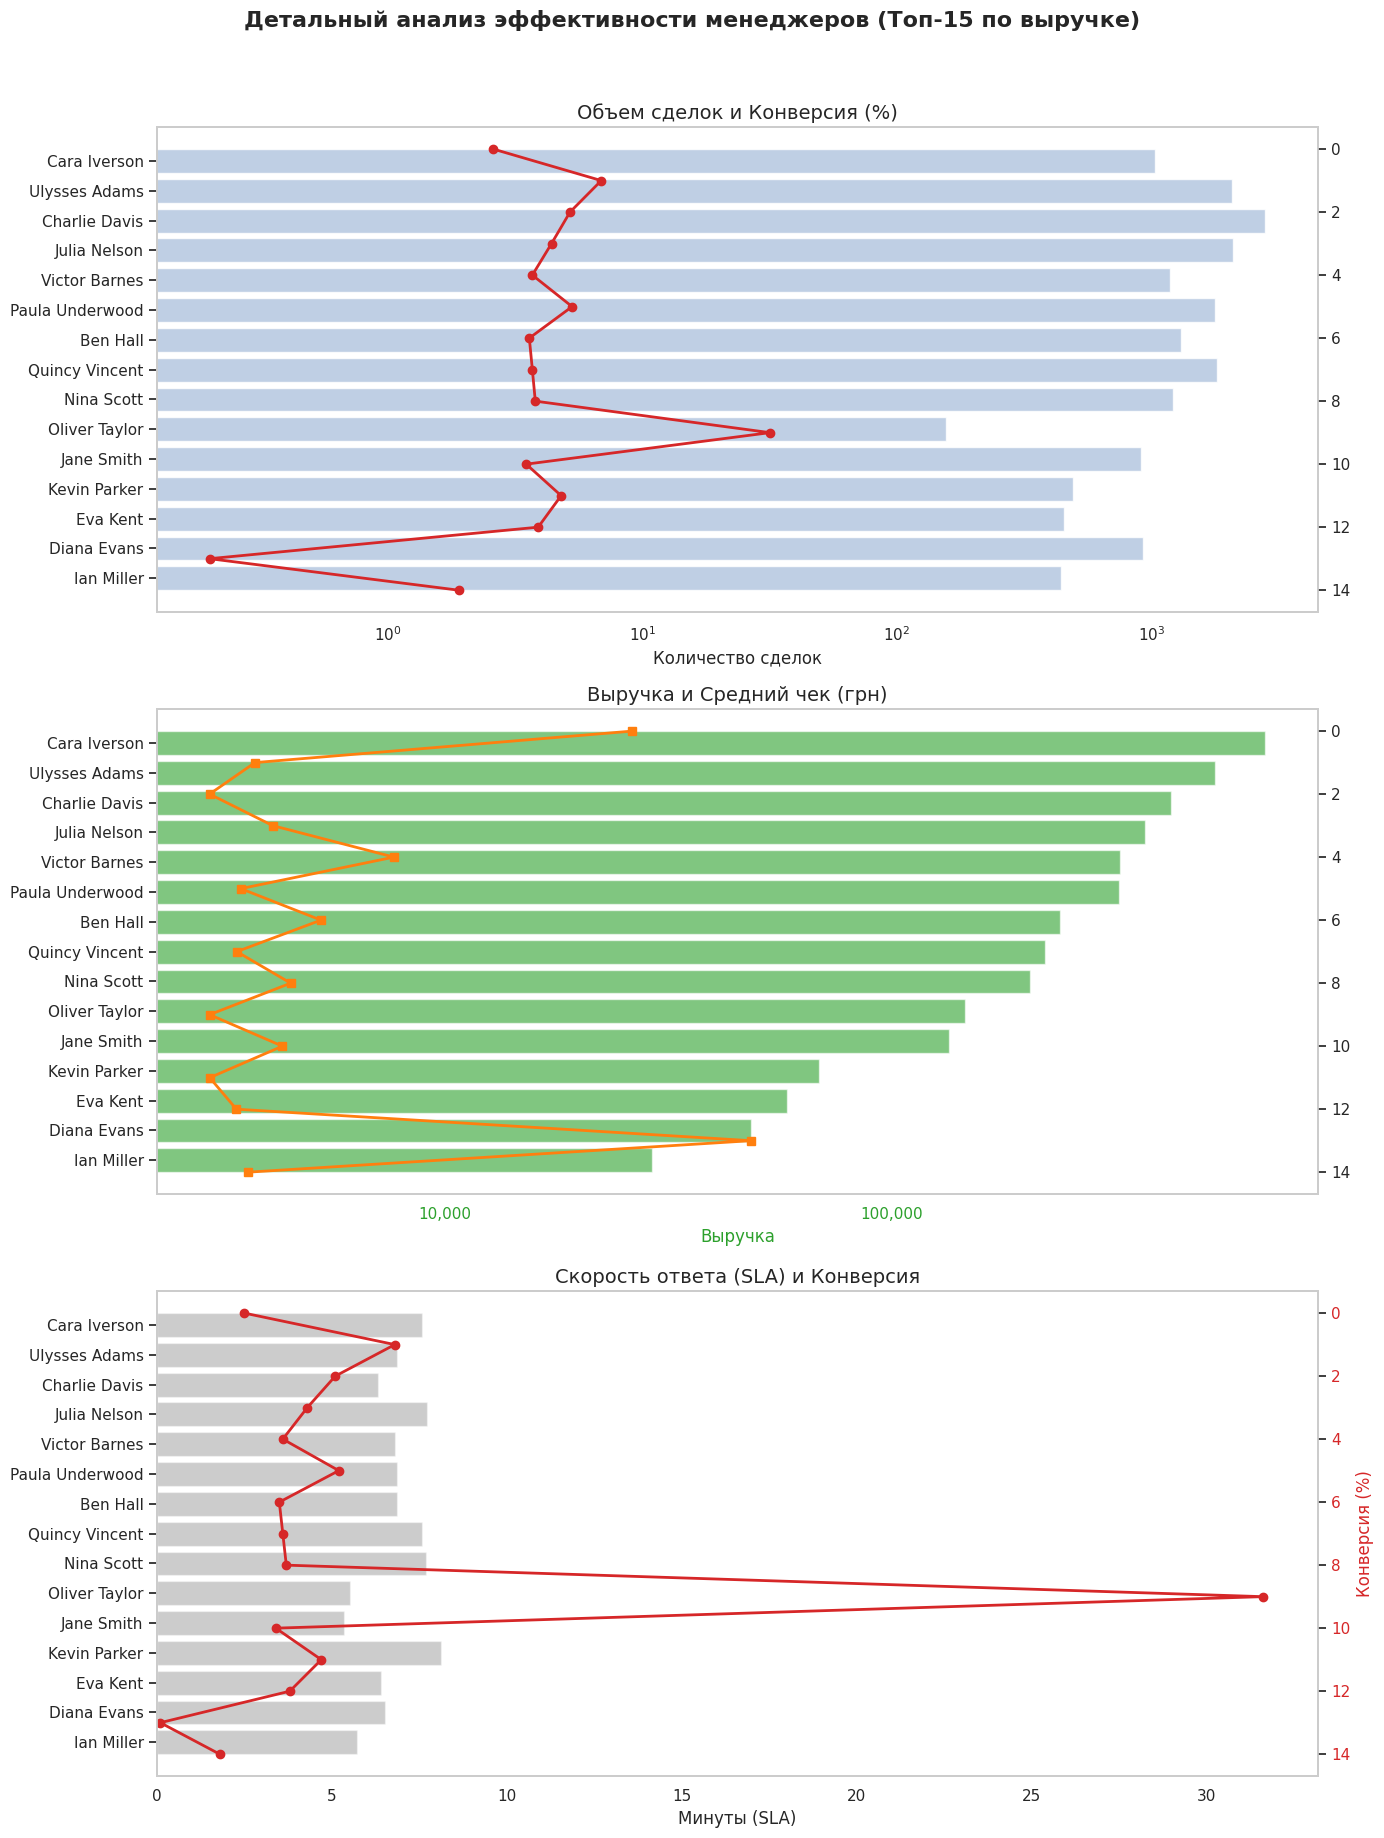

In [31]:
manager_stats = (
    deals[deals['deal_owner_name'] != 'Unknown']
    .groupby('deal_owner_name', observed=True)
    .agg(
        total_deals=('id', 'count'),
        buyers=('is_buyer', 'sum'),
        revenue=('initial_amount_paid', 'sum'),
        avg_sla_min=('sla', lambda x: x.dropna().mean() / 60)
    )
    .assign(
        conversion_rate=lambda x: (x['buyers'] / x['total_deals'] * 100).round(1),
        avg_revenue_per_deal=lambda x: (x['revenue'] / x['buyers']).where(x['buyers'] > 0).round(0)
    )
    .sort_values('revenue', ascending=False)
)

top_managers = manager_stats.head(15)
y_pos = range(len(top_managers))
names = top_managers.index

fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharey=False)

# График 1: Число сделок + Конверсия (Log Scale)
ax = axes[0]
ax.barh(y_pos, top_managers['total_deals'], color='lightsteelblue', alpha=0.8, label='Сделки')
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_title('Объем сделок и Конверсия (%)', fontsize=14)
ax.set_xlabel('Количество сделок')
ax.grid(False)

ax_r = ax.twinx()
ax_r.plot(top_managers['conversion_rate'].values + 0.1, y_pos, color='#d62728', marker='o', linewidth=2, markersize=6, label='Конверсия %')
ax_r.set_xscale('log') 
ax_r.set_xlabel('Конверсия (%) - Log Scale', color='#d62728')
ax_r.tick_params(axis='x', labelcolor='#d62728')
ax_r.invert_yaxis()
ax_r.grid(False)

# График 2: Выручка + Средний чек
ax = axes[1]
ax.barh(y_pos, top_managers['revenue'], color='#2ca02c', alpha=0.6, label='Выручка') 
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_title('Выручка и Средний чек (грн)', fontsize=14)
ax.set_xlabel('Выручка', color='#2ca02c')
ax.tick_params(axis='x', labelcolor='#2ca02c')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(False)

ax_r = ax.twinx()
ax_r.plot(top_managers['avg_revenue_per_deal'].values + 1, y_pos, color='#ff7f0e', marker='s', linewidth=2, markersize=6, label='Средний чек')
ax_r.set_xscale('log') 
ax_r.set_xlabel('Средний чек - Log Scale', color='#ff7f0e')
ax_r.tick_params(axis='x', labelcolor='#ff7f0e')
ax_r.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_r.invert_yaxis()
ax_r.grid(False)

# График 3: SLA + Конверсия
ax = axes[2]
ax.barh(y_pos, top_managers['avg_sla_min'], color='grey', alpha=0.4, label='Среднее SLA (мин)')
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_title('Скорость ответа (SLA) и Конверсия', fontsize=14)
ax.set_xlabel('Минуты (SLA)')
ax.grid(False)

ax_r = ax.twinx()
ax_r.plot(top_managers['conversion_rate'].values, y_pos, color='#d62728', marker='o', linewidth=2, markersize=6, label='Конверсия %')
ax_r.set_ylabel('Конверсия (%)', color='#d62728')
ax_r.tick_params(axis='y', labelcolor='#d62728')
ax_r.invert_yaxis()
ax_r.grid(False)

plt.suptitle('Детальный анализ эффективности менеджеров (Топ-15 по выручке)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# print('--- Таблица: Рейтинг менеджеров ---')
# display(manager_stats[['total_deals', 'buyers', 'conversion_rate', 'revenue', 'avg_revenue_per_deal', 'avg_sla_min']].round(1))


### Воронка продаж

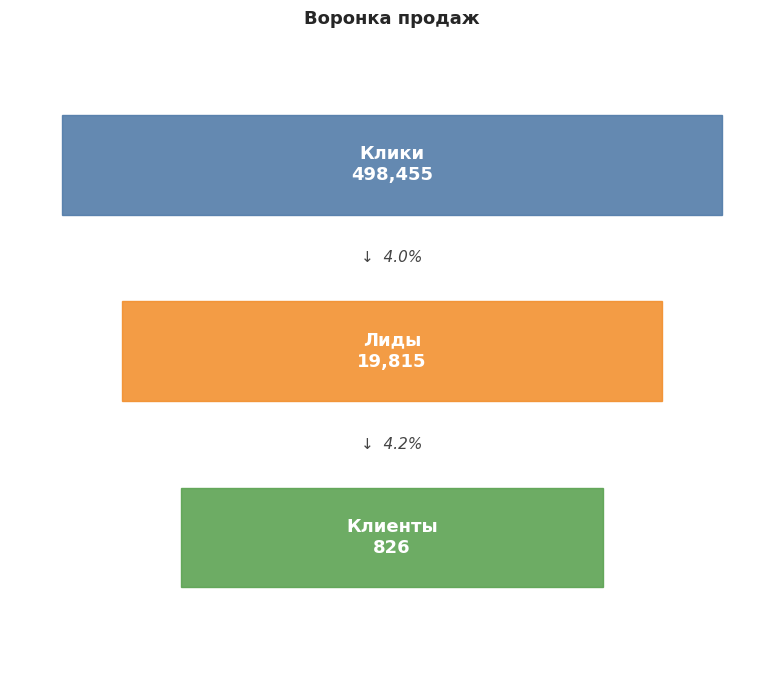

Кликов:   498,455
Лидов:    19,815   (Клики → Лиды:    3.98%)
Клиентов: 826    (Лиды → Клиенты:  4.17%)


In [32]:
n_clicks = int(spend['clicks'].sum())
n_leads  = int(len(deals))
n_buyers = int(deals['is_buyer'].sum())

stages  = ['Клики', 'Лиды', 'Клиенты']
values  = [n_clicks, n_leads, n_buyers]
colors  = ['#4e79a7', '#f28e2b', '#59a14f']

conv_click_lead = n_leads  / n_clicks * 100 if n_clicks else 0
conv_lead_buyer = n_buyers / n_leads  * 100 if n_leads  else 0
conv_labels = [None, f'{conv_click_lead:.1f}%', f'{conv_lead_buyer:.1f}%']

log_vals = np.log1p(values)
half_widths = 0.25 + (log_vals / log_vals[0]) * 0.70  # диапазон [0.25 .. 0.95]

# Воронка
fig, ax = plt.subplots(figsize=(8, 7))
ax.axis('off')

block_h = 0.4
gap     = 0.35
total_h = len(stages) * block_h + (len(stages) - 1) * gap
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-gap, total_h + 0.3)

for i, (stage, val, color, hw) in enumerate(zip(stages, values, colors, half_widths)):
    y_bot = total_h - (i + 1) * block_h - i * gap

    rect = plt.Rectangle((-hw, y_bot), 2 * hw, block_h,
                          color=color, alpha=0.88, zorder=2)
    ax.add_patch(rect)

    ax.text(0, y_bot + block_h / 2,
            f'{stage}\n{val:,}',
            ha='center', va='center',
            fontsize=13, fontweight='bold', color='white', zorder=3)

    if conv_labels[i]:
        ax.text(0, y_bot + block_h + gap / 2,
                f'↓  {conv_labels[i]}',
                ha='center', va='center',
                fontsize=11, color='#444444', fontstyle='italic', zorder=3)

ax.set_title('Воронка продаж',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print(f'Кликов:   {n_clicks:,}')
print(f'Лидов:    {n_leads:,}   (Клики → Лиды:    {conv_click_lead:.2f}%)')
print(f'Клиентов: {n_buyers:,}    (Лиды → Клиенты:  {conv_lead_buyer:.2f}%)')


## Анализ платежей и продуктов

### Типы оплаты и их влияние на успешность сделок

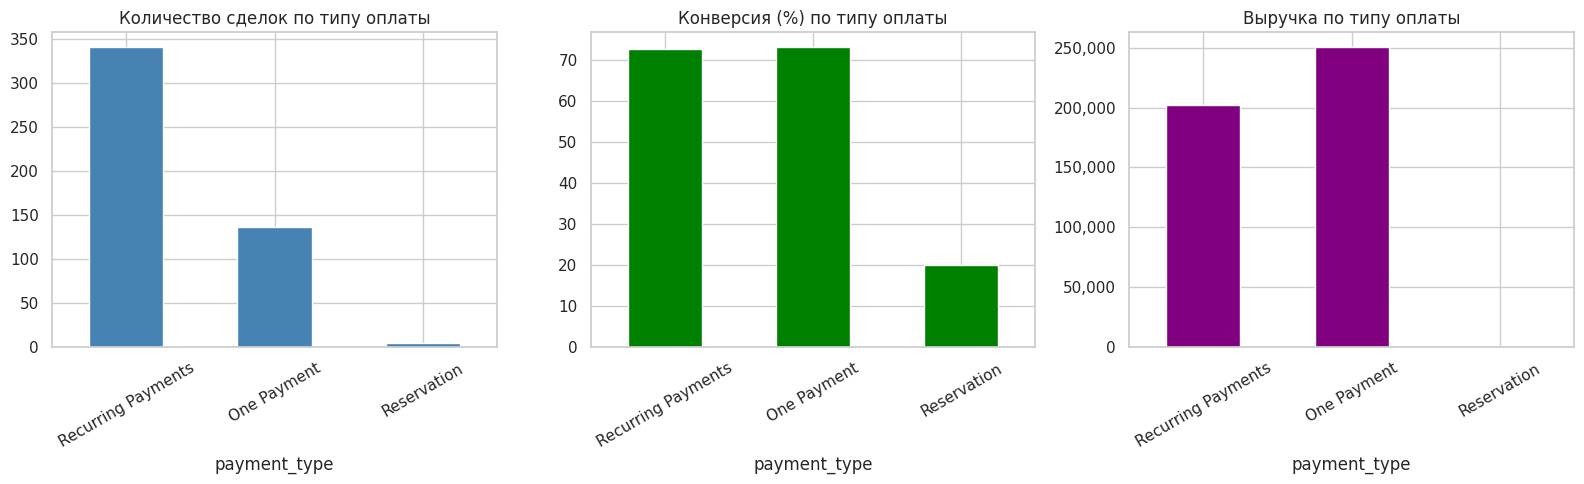

,count,buyers,revenue,conversion_rate
payment_type,,,,
Recurring Payments,341,248,202059.00,72.70
One Payment,137,100,250151.00,73.00
Reservation,5,1,900.00,20.00


In [33]:
payment_stats = (
    deals[deals['payment_type'] != 'Unknown']
    .groupby('payment_type', observed=True)
    .agg(
        count=('id', 'count'),
        buyers=('is_buyer', 'sum'),
        revenue=('initial_amount_paid', 'sum')
    )
    .assign(conversion_rate=lambda x: (x['buyers'] / x['count'] * 100).round(1))
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

payment_stats['count'].plot.bar(ax=axes[0], color='steelblue', rot=30)
axes[0].set_title('Количество сделок по типу оплаты')

payment_stats['conversion_rate'].plot.bar(ax=axes[1], color='green', rot=30)
axes[1].set_title('Конверсия (%) по типу оплаты')

payment_stats['revenue'].plot.bar(ax=axes[2], color='purple', rot=30)
axes[2].set_title('Выручка по типу оплаты')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

display(payment_stats)

### Продукты: популярность и успешность

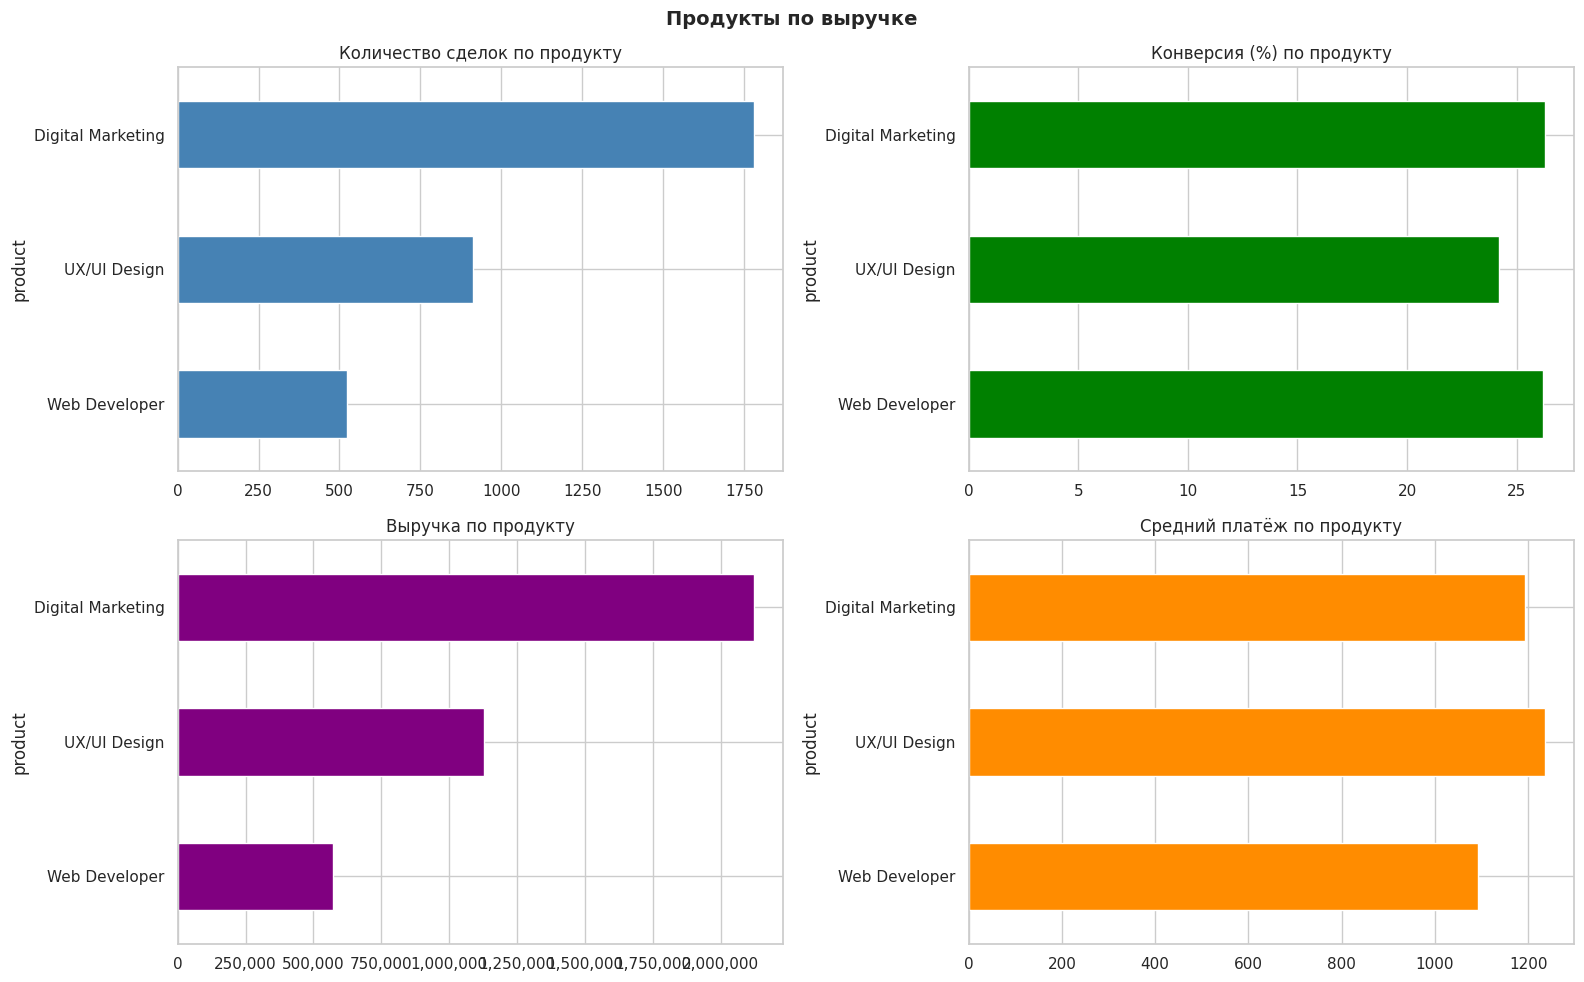

,count,buyers,revenue,avg_paid,conversion_rate
product,,,,,
Digital Marketing,1781,468,2122959.00,1192.00,26.30
UX/UI Design,913,221,1128700.00,1236.25,24.20
Web Developer,523,137,571650.00,1093.02,26.20


In [34]:
# Анализ продуктов: исключаем Unknown, "Find yourself in IT" (не является курсом) и те, по которым не было выручки
excluded_products = ['Unknown', 'Find yourself in IT']

product_stats = (
    deals[
        (~deals['product'].isin(excluded_products)) & 
        (deals['initial_amount_paid'] > 0)
    ]
    .groupby('product', observed=True)
    .agg(
        count=('id', 'count'),
        buyers=('is_buyer', 'sum'),
        revenue=('initial_amount_paid', 'sum'),
        avg_paid=('initial_amount_paid', lambda x: x[x > 0].mean())
    )
    .assign(conversion_rate=lambda x: (x['buyers'] / x['count'] * 100).round(1))
    .sort_values('revenue', ascending=False)
)

top_products = product_stats.head(15)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

top_products['count'].plot.barh(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Количество сделок по продукту')
axes[0, 0].invert_yaxis()

top_products['conversion_rate'].plot.barh(ax=axes[0, 1], color='green')
axes[0, 1].set_title('Конверсия (%) по продукту')
axes[0, 1].invert_yaxis()

top_products['revenue'].plot.barh(ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Выручка по продукту')
axes[1, 0].invert_yaxis()
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

top_products['avg_paid'].plot.barh(ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Средний платёж по продукту')
axes[1, 1].invert_yaxis()

plt.suptitle('Продукты по выручке', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(product_stats)


### Тип обучения

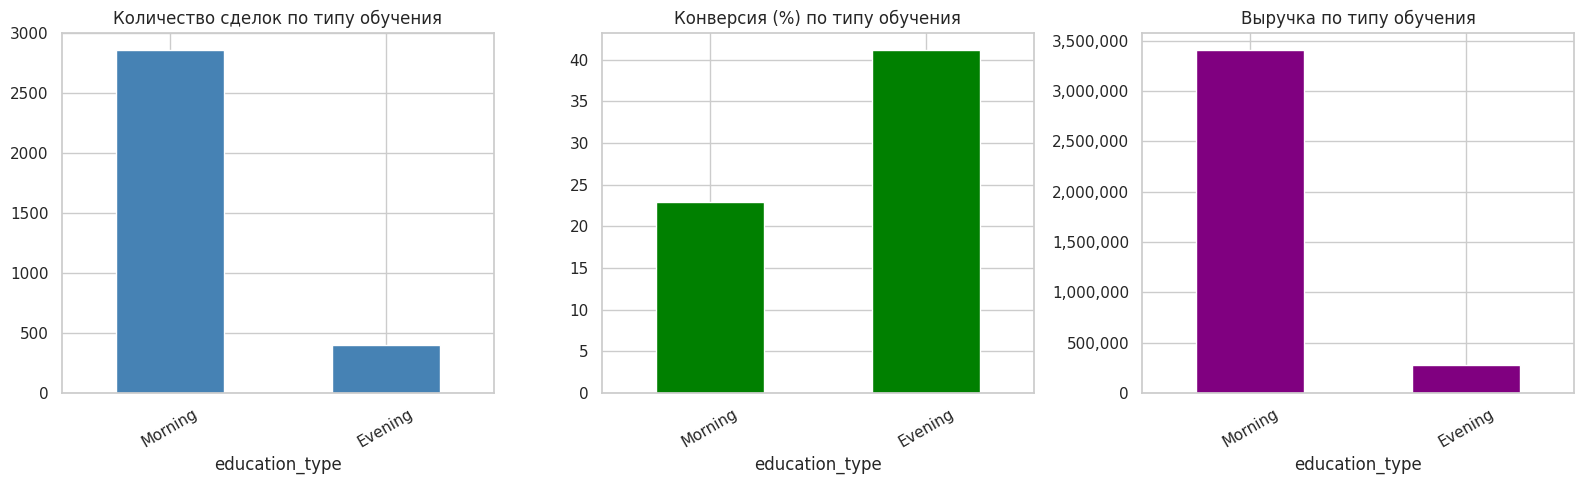

,count,buyers,revenue,conversion_rate
education_type,,,,
Morning,2858,655,3409550.00,22.90
Evening,398,164,274059.00,41.20


In [35]:
if 'education_type' in deals.columns:
    edu_stats = (
        deals[deals['education_type'] != 'Unknown']
        .groupby('education_type', observed=True)
        .agg(
            count=('id', 'count'),
            buyers=('is_buyer', 'sum'),
            revenue=('initial_amount_paid', 'sum')
        )
        .assign(conversion_rate=lambda x: (x['buyers'] / x['count'] * 100).round(1))
        .sort_values('count', ascending=False)
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    edu_stats['count'].plot.bar(ax=axes[0], color='steelblue', rot=30)
    axes[0].set_title('Количество сделок по типу обучения')

    edu_stats['conversion_rate'].plot.bar(ax=axes[1], color='green', rot=30)
    axes[1].set_title('Конверсия (%) по типу обучения')

    edu_stats['revenue'].plot.bar(ax=axes[2], color='purple', rot=30)
    axes[2].set_title('Выручка по типу обучения')
    axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.show()

    display(edu_stats)
else:
    print('Колонка education_type отсутствует в данных.')

## Географический анализ

### Распределение сделок по городам

In [36]:
# Агрегация по городам
city_stats = (
    deals[~deals['city'].isin(['Unknown', '-', '', 'None'])]
    .groupby('city', observed=True)
    .agg(
        count=('id', 'count'),
        buyers=('is_buyer', 'sum'),
        revenue=('initial_amount_paid', 'sum')
    )
    .assign(conversion_rate=lambda x: (x['buyers'] / x['count'] * 100).round(1))
    .sort_values('count', ascending=False)
)

# Загрузка координат
COORDS_PATH = os.path.join('..', 'data', 'city_coords.json')
city_coords = {}
if os.path.exists(COORDS_PATH):
    with open(COORDS_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)
        city_coords = {k: tuple(v) for k, v in data.items() if k not in ['Unknown', '-', '']}

# Кластеризация
RADIUS_KM = 40
available_cities = [c for c in city_stats.index if c in city_coords]
sorted_cities = sorted(available_cities, key=lambda c: city_stats.loc[c, 'count'], reverse=True)
clusters = []
assigned = set()

for city in sorted_cities:
    if city in assigned: continue
    cluster = [city]
    assigned.add(city)
    for other in sorted_cities:
        if other in assigned: continue
        if geodesic(city_coords[city], city_coords[other]).km <= RADIUS_KM:
            cluster.append(other)
            assigned.add(other)
    clusters.append(cluster)

cluster_rows = []
for cluster in clusters:
    center_city = cluster[0]
    sub = city_stats.loc[[c for c in cluster if c in city_stats.index]]
    cluster_rows.append({
        'label': center_city if len(cluster) == 1 else f'{center_city} +{len(cluster)-1}',
        'lat': city_coords[center_city][0],
        'lon': city_coords[center_city][1],
        'count': int(sub['count'].sum()),
        'buyers': int(sub['buyers'].sum()),
        'revenue': float(sub['revenue'].sum()),
        'conversion_rate': round(sub['buyers'].sum() / sub['count'].sum() * 100, 1)
    })
cluster_df = pd.DataFrame(cluster_rows)

# Карта
m = folium.Map(location=[50.0, 20.0], zoom_start=4, tiles='CartoDB positron')

# Для Circle (в метрах) подберем масштаб, чтобы круги не перекрывали всё
# Базовый радиус 20км для самого крупного города, остальные пропорционально площади (sqrt)
max_count = cluster_df['count'].max()
base_radius_meters = 50000 # 50 км для максимума

for _, row in cluster_df.iterrows():
    # Используем sqrt для масштабирования по площади круга, а не по радиусу
    # Это визуально честнее отображает разницу в объемах
    radius_meters = base_radius_meters * np.sqrt(row['count'] / max_count)
    
    color = '#27ae60' if row['conversion_rate'] >= 15 else '#f39c12' if row['conversion_rate'] >= 8 else '#e74c3c'
    
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=max(radius_meters, 5000), # минимум 5км чтобы было видно
        color=color,
        weight=1,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=folium.Popup(f"<b>{row['label']}</b><br>Сделок: {row['count']:,}<br>Конверсия: {row['conversion_rate']}%", max_width=200),
        tooltip=row['label']
    ).add_to(m)

display(m)


### Уровень немецкого языка и success rate по городам

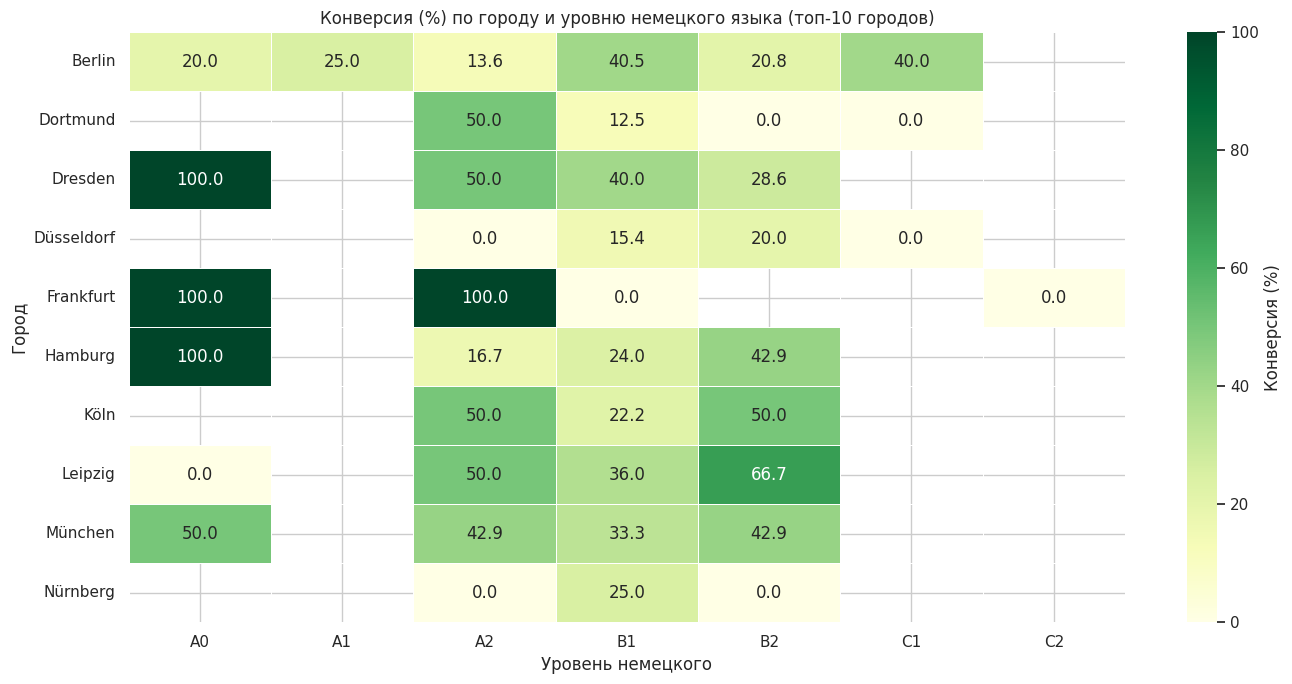

--- Конверсия по уровню немецкого (все города) ---


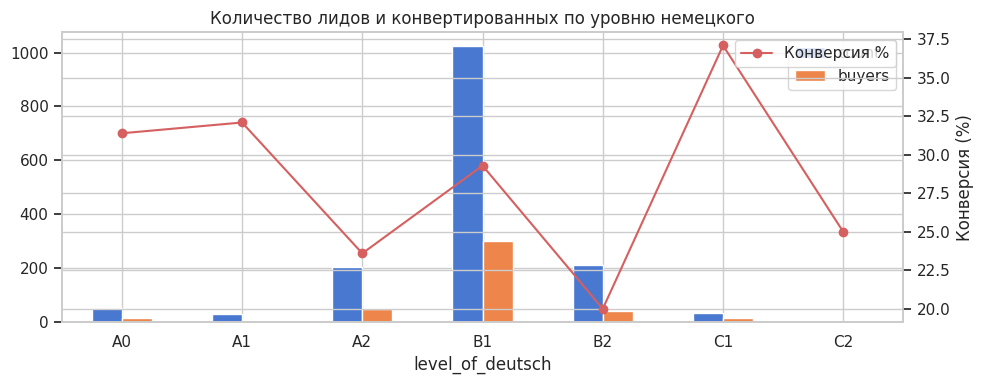

,count,buyers,conversion_rate
level_of_deutsch,,,
A0,51,16,31.40
A1,28,9,32.10
A2,203,48,23.60
B1,1024,300,29.30
B2,210,42,20.00
C1,35,13,37.10
C2,4,1,25.00


In [37]:
# Топ-10 городов по количеству сделок
top10_cities = city_stats.head(10).index.tolist()

city_level = (
    deals[
        (deals['city'].isin(top10_cities)) &
        (deals['level_of_deutsch'] != 'Unknown')
    ]
    .groupby(['city', 'level_of_deutsch'], observed=True)
    .agg(count=('id', 'count'), buyers=('is_buyer', 'sum'))
    .assign(conversion_rate=lambda x: (x['buyers'] / x['count'] * 100).round(1))
    .reset_index()
)

# Сводная таблица: конверсия по городу × уровень языка
pivot_conv = city_level.pivot_table(
    index='city', columns='level_of_deutsch',
    values='conversion_rate', aggfunc='mean'
)

# Упорядочиваем уровни
cefr_order = ['A0', 'A1', 'A2', 'B1', 'B2', 'C1', 'C2']
ordered_cols = [c for c in cefr_order if c in pivot_conv.columns]
pivot_conv = pivot_conv[ordered_cols].astype(float)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot_conv, annot=True, fmt='.1f', cmap='YlGn',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Конверсия (%)'}
)
ax.set_title('Конверсия (%) по городу и уровню немецкого языка (топ-10 городов)')
ax.set_xlabel('Уровень немецкого')
ax.set_ylabel('Город')
plt.tight_layout()
plt.show()

# Общий срез: уровень языка → конверсия
print('--- Конверсия по уровню немецкого (все города) ---')
lang_overall = (
    deals[deals['level_of_deutsch'] != 'Unknown']
    .groupby('level_of_deutsch', observed=True)
    .agg(count=('id', 'count'), buyers=('is_buyer', 'sum'))
    .assign(conversion_rate=lambda x: (x['buyers'] / x['count'] * 100).round(1))
    .reindex([c for c in cefr_order if c in deals['level_of_deutsch'].unique().tolist()])
)

fig, ax = plt.subplots(figsize=(10, 4))
lang_overall[['count', 'buyers']].plot.bar(ax=ax, rot=0)
ax.set_title('Количество лидов и конвертированных по уровню немецкого')
ax2 = ax.twinx()
ax2.plot(range(len(lang_overall)), lang_overall['conversion_rate'], 'r-o', label='Конверсия %')
ax2.set_ylabel('Конверсия (%)')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

display(lang_overall)


## Выводы

### Маркетинг (источники и кампании)

**Google Ads** — крупнейший источник лидов, но при этом имеет самый низкий ROMI среди платных каналов: расходы сопоставимы с выручкой. Это классическая ситуация масштабирования без оптимизации — бюджет растёт, но качество трафика (конверсия Клики → Лиды → Покупка) не улучшается. Если не вмешаться, Google Ads продолжит «съедать» бюджет при нейтральном вкладе в прибыль, тогда как органические и реферальные каналы, несмотря на меньший объём, демонстрируют более высокий ROMI.

**Что сделать:** провести аудит кампаний Google Ads — отключить ключевые слова с низкой конверсией, перераспределить бюджет в пользу источников с положительным ROMI. Для каждого источника установить целевой CAC (Cost per Acquisition) и контролировать его еженедельно.

---

### Воронка продаж

Конверсия **Клики → Лиды** и **Лиды → Клиенты** — два самостоятельных узких места. Снижение конверсии на первом этапе указывает на несоответствие рекламного послания целевой аудитории (нерелевантный трафик). Снижение на втором — на проблемы внутри отдела продаж: скорость ответа (SLA), качество обработки лида, наличие скриптов.

**Что сделать:** разделить ответственность — маркетинг отвечает за CTR и CPL, продажи — за C1 (Лиды → Покупки). Ставить цели на каждый этап независимо и отслеживать их в динамике.

---

### Продолжительность сделок

Выигранные сделки (Won/Paid) закрываются быстрее проигранных (Lost): медианная длительность у Won короче, а хвост распределения у Lost длиннее. Это означает, что чем дольше сделка «висит» в работе без результата, тем выше вероятность её потери — менеджеры тратят время на нежизнеспособные лиды.

**Что сделать:** ввести дедлайн на обработку лида (например, 14 дней в Active Sales) — после чего автоматически переводить сделку в Lost. Это освободит время менеджеров и сделает воронку «живой».

---

### Эффективность менеджеров

У одного менеджера (Kevin Parker) сконцентрированы **14 из 28 Won/Paid сделок с нулевой оплатой** — это сигнал либо систематической ошибки в работе с CRM, либо намеренной манипуляции показателем конверсии. Также выявлены менеджеры с высокой долей отрицательных длительностей сделок (дата закрытия раньше даты создания), что говорит о проблемах при вводе данных.

**Что сделать:** провести персональный разбор с Kevin Parker по 14 аномальным сделкам. Для всех менеджеров ввести валидацию в CRM: нельзя закрыть сделку в Won/Paid без фактической суммы оплаты > 0 и предоставленного сервиса (число месяцев обучения > 0).

---

### Продуктовый и географический срез

Сильный разброс конверсии по уровням немецкого языка (A0–B1 слабее, B2–C1 выше) указывает на более высокую готовность к покупке у клиентов с продвинутым уровнем — сегмент, который выгоднее привлекать целенаправленно.

Географически лиды сконцентрированы в крупных городах, при этом конверсия по регионам существенно различается (зелёные / жёлтые / красные кластеры на карте).

**Что сделать:** сфокусировать рекламный бюджет на аудитории B2–C1 (более высокая конверсия и средний чек), перевести рекламу в топ-городах с конверсией < 8% в тестовый режим до выявления причины низкого качества.